In [11]:
import cv2
import numpy as np
import requests

In [3]:
img = cv2.imread("1.jpg")

(-0.5, 1914.5, 2559.5, -0.5)

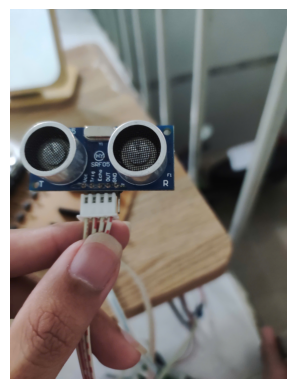

In [4]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")


In [5]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)


(-0.5, 1914.5, 2559.5, -0.5)

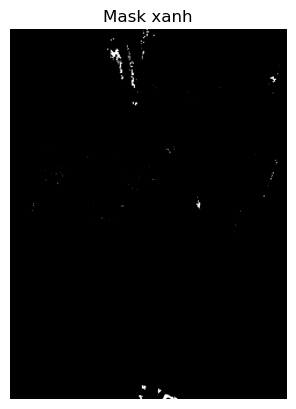

In [6]:
# Ngưỡng màu xanh lá
lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])

mask = cv2.inRange(hsv, lower_green, upper_green)

plt.imshow(mask, cmap="gray")
plt.title("Mask xanh")
plt.axis("off")


In [7]:
total_pixels = mask.size
green_pixels = cv2.countNonZero(mask)

green_ratio = green_pixels / total_pixels * 100

green_ratio


0.27955695169712796

In [8]:
if green_ratio > 20:
    print("✅ Vườn TỐT – Nhiều cây xanh")
else:
    print("⚠️ Vườn KHÔNG TỐT – Ít cây xanh")


⚠️ Vườn KHÔNG TỐT – Ít cây xanh


In [ ]:
# ====== LINK ẢNH TỪ CLOUDINARY ======
IMAGE_URL = "DÁN_URL_ẢNH_CLOUDINARY_VÀO_ĐÂY"

# ====== TẢI ẢNH TỪ CLOUD VỀ RAM ======
img_data = requests.get(IMAGE_URL).content
img_array = np.frombuffer(img_data, np.uint8)
img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

# ====== ĐỔI SANG HSV ======
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# ====== NGƯỠNG MÀU XANH ======
lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])

# ====== TẠO MASK ======
mask = cv2.inRange(hsv, lower_green, upper_green)

# ====== TÍNH % MÀU XANH ======
total_pixels = mask.size
green_pixels = cv2.countNonZero(mask)
green_ratio = green_pixels / total_pixels * 100

print("Tỷ lệ màu xanh:", round(green_ratio, 2), "%")

# ====== KẾT LUẬN ======
if green_ratio > 20:
    print("✅ VƯỜN TỐT – Nhiều cây xanh")
else:
    print("⚠️ VƯỜN KHÔNG TỐT – Ít cây xanh")